In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
import json
import pandas as pd
import cv2
import re

from project_root import PROJECT_ROOT, DATASETS_ROOT

In [2]:
# ds_root = DATASETS_ROOT / "elephants/training_data"
ds_root = Path("/home/dherrera/data/elephants/identity/videos/src/identity_days")

all_video_files = list(ds_root.glob("**/*.mp4"))
print(f"Dataset at {str(ds_root)} has {len(all_video_files)} total videos")

Dataset at /home/dherrera/data/elephants/identity/videos/src/identity_days has 72 total videos


In [3]:
CAMERA_NAMES = [
    "zag_elp_cam_016",
    "zag_elp_cam_017",
    "zag_elp_cam_018",
    "zag_elp_cam_019",
]


def parse_video_time(filename: str) -> tuple[str, datetime.datetime]:
    filename = filename.lower()

    # Name is in the shape:
    # {camera}-{dd.mm.yyyy}-{time_start}-{time_end}.mp4

    # Parse {camera}
    camera_prefixes = [
        camera_name
        for camera_name in CAMERA_NAMES
        if filename.replace("-", "_").startswith(camera_name)
    ]
    assert len(camera_prefixes) == 1
    camera_prefix = camera_prefixes[0]

    # Remove camera prefix
    filename = filename[len(camera_prefix) + 1 :]

    # Parse {date}
    if filename[2] == ".":
        # Name is in format {dd.mm.yyyy}-{hhmmss}-{hhmmss}_{iiiiiiii}_img.jpg
        match = re.search(
            "(?P<day>\d{2}).(?P<month>\d{2}).(?P<year>\d{4})-(?P<hour0>\d{2})(?P<min0>\d{2})(?P<sec0>\d{2})-(?P<hour1>\d{2})(?P<min1>\d{2})(?P<sec1>\d{2})",
            filename,
        )
        if match is None:
            raise RuntimeError(f"Could not parse {filename}")
    else:
        # Name is in format {yyyymmdd}-{hhmmss}_{iiiiiiii}_img.jpg
        match = re.search(
            "(?P<year>\d{4})(?P<month>\d{2})(?P<day>\d{2})-(?P<hour0>\d{2})(?P<min0>\d{2})(?P<sec0>\d{2})",
            filename,
        )
        if match is None:
            raise RuntimeError(f"Could not parse {filename}")
    fields = {k: int(v) for k, v in match.groupdict().items()}

    time_point = datetime.datetime(
        *[fields[k] for k in ["year", "month", "day", "hour0", "min0", "sec0"]]
    )
    return camera_prefix, time_point


name = all_video_files[4].name
print(name)
print(parse_video_time(name))

all_video_data = [parse_video_time(f.name) for f in all_video_files]
camera_from_name = {f.name: d[0] for f, d in zip(all_video_files, all_video_data)}
time_from_name = {f.name: d[1] for f, d in zip(all_video_files, all_video_data)}

ZAG-ELP-CAM-016-27.01.2025-100029-140029.mp4
('zag_elp_cam_016', datetime.datetime(2025, 1, 27, 10, 0, 29))


In [4]:
def json_from_video_file(filename: Path) -> Path:
    return Path(str(filename).replace(".mp4", "_points.json"))


all_json_files = [json_from_video_file(f) for f in all_video_files]
has_json = [f.exists() for f in all_json_files]
print(
    f"There are {np.sum(has_json)} ({np.sum(has_json)/len(has_json):.1%}) videos with annotations."
)

There are 37 (51.4%) videos with annotations.


In [5]:
# Load labels
FPS = 25.0026

labels = []
for video_file in all_video_files:
    json_file = json_from_video_file(video_file)
    if not json_file.exists():
        continue
    with json_file.open() as f:
        annotations = json.load(f)

        camera = camera_from_name[video_file.name]
        camera = camera.replace("-", "_")
        video_start_time = time_from_name[video_file.name]

        for frame_annotations in annotations:
            frame_idx = frame_annotations["frame"]
            frame_time = video_start_time + datetime.timedelta(seconds=frame_idx / FPS)

            for record in frame_annotations["records"]:
                label = record["name"]
                ppoints = np.array(record["ppoints"])
                center = np.mean(ppoints, axis=0)
                labels.append((camera, frame_time, label, center[0], center[1]))

df_labels = pd.DataFrame(
    labels, columns=["camera", "time", "label", "center_x", "center_y"]
)
df_labels

,camera,time,label,center_x,center_y
0,zag_elp_cam_016,2025-01-25 06:51:16.883020,Indi,1234.446457,357.815443
1,zag_elp_cam_016,2025-01-25 06:51:16.883020,Chandra,899.341502,402.184557
2,zag_elp_cam_016,2025-01-25 06:52:27.955629,Chandra,935.143314,385.009416
3,zag_elp_cam_016,2025-01-25 06:52:27.955629,Indi,943.735749,530.998117
4,zag_elp_cam_016,2025-01-25 06:55:32.176470,Indi,832.750133,754.274953
...,...,...,...,...,...
1041,zag_elp_cam_019,2025-01-27 21:37:54.016358,Thai,1584.128000,273.109017
1042,zag_elp_cam_019,2025-01-27 21:42:18.948805,Thai,921.600000,176.958277
1043,zag_elp_cam_019,2025-01-27 21:43:03.104213,Thai,2045.952000,1194.724092
1044,zag_elp_cam_019,2025-01-27 21:57:35.173518,Thai,1120.256000,1078.115747


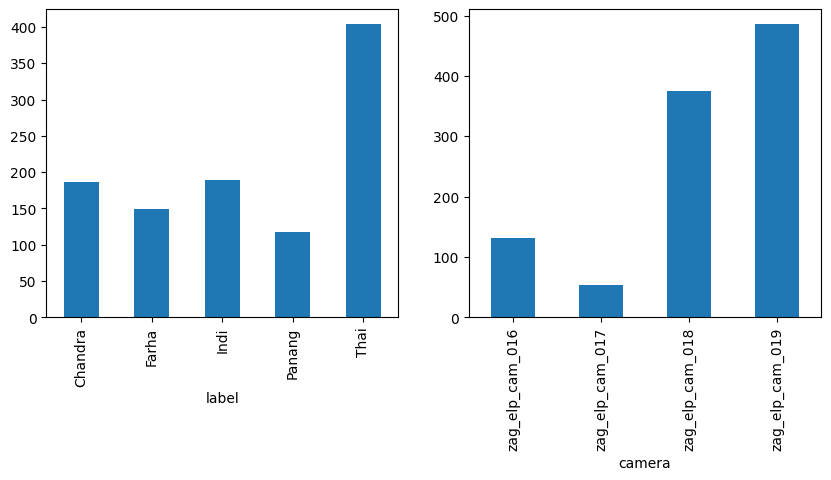

In [6]:
#############################################3
# Check distribution per label
def plot_global_hist():
    fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
    df_labels.groupby("label")["center_x"].count().plot(kind="bar", ax=axs[0])
    df_labels.groupby("camera")["center_x"].count().plot(kind="bar", ax=axs[1])


plot_global_hist()

In [7]:
# Add a column that is time only but with datetime type
df_labels["today"] = datetime.date.today()
ds_time_only = df_labels["time"] - df_labels["time"].dt.normalize()
df_labels["fake_date"] = df_labels["today"].astype("datetime64[s]") + ds_time_only
df_labels

,camera,time,label,center_x,center_y,today,fake_date
0,zag_elp_cam_016,2025-01-25 06:51:16.883020,Indi,1234.446457,357.815443,2025-03-07,2025-03-07 06:51:16.883020
1,zag_elp_cam_016,2025-01-25 06:51:16.883020,Chandra,899.341502,402.184557,2025-03-07,2025-03-07 06:51:16.883020
2,zag_elp_cam_016,2025-01-25 06:52:27.955629,Chandra,935.143314,385.009416,2025-03-07,2025-03-07 06:52:27.955629
3,zag_elp_cam_016,2025-01-25 06:52:27.955629,Indi,943.735749,530.998117,2025-03-07,2025-03-07 06:52:27.955629
4,zag_elp_cam_016,2025-01-25 06:55:32.176470,Indi,832.750133,754.274953,2025-03-07,2025-03-07 06:55:32.176470
...,...,...,...,...,...,...,...
1041,zag_elp_cam_019,2025-01-27 21:37:54.016358,Thai,1584.128000,273.109017,2025-03-07,2025-03-07 21:37:54.016358
1042,zag_elp_cam_019,2025-01-27 21:42:18.948805,Thai,921.600000,176.958277,2025-03-07,2025-03-07 21:42:18.948805
1043,zag_elp_cam_019,2025-01-27 21:43:03.104213,Thai,2045.952000,1194.724092,2025-03-07,2025-03-07 21:43:03.104213
1044,zag_elp_cam_019,2025-01-27 21:57:35.173518,Thai,1120.256000,1078.115747,2025-03-07,2025-03-07 21:57:35.173518


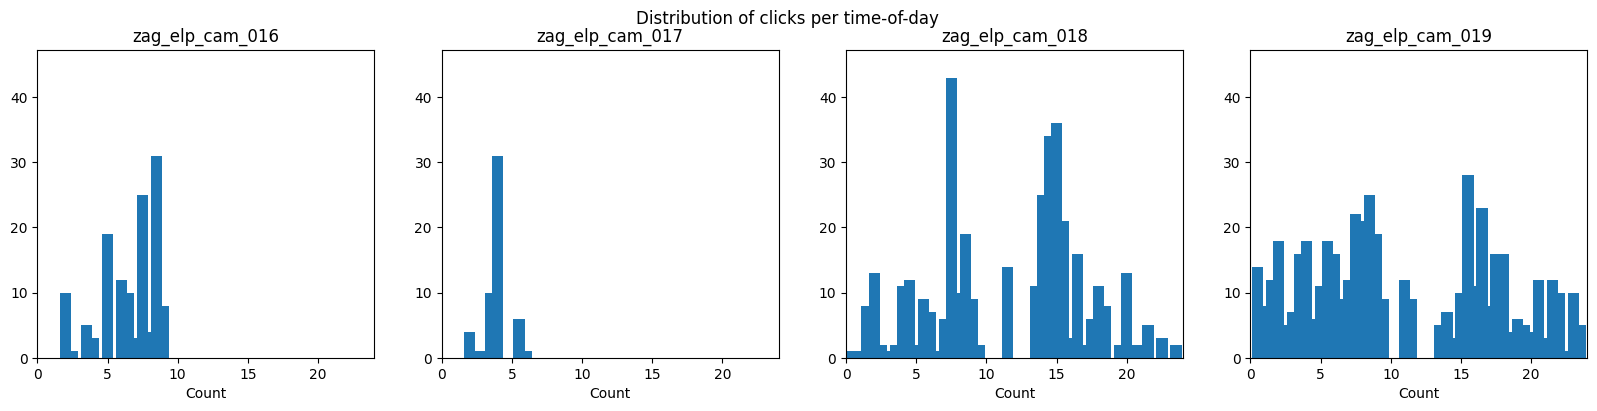

In [8]:
counts_per_time = {}
df = df_labels.set_index(df_labels["fake_date"])
for i, (camera, df_camera) in enumerate(df.groupby("camera")):
    counts = df_camera["time"].resample("30min", origin="start_day").count()
    counts_per_time[camera] = counts.reset_index()
max_count = np.max([np.max(c["time"].to_numpy()) for c in counts_per_time.values()])


def plot_counts_per_time():
    NCOLS = 4
    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 4))
    axs = axs.reshape(-1)
    for i, (camera, counts) in enumerate(counts_per_time.items()):
        hours = counts["fake_date"].dt.hour + counts["fake_date"].dt.minute / 60

        ax = axs[i]
        ax.bar(hours, counts["time"])
        ax.set_xlim([0, 24])
        ax.set_ylim([0, max_count * 1.1])
        ax.set_title(camera)
        ax.set_xlabel("Time of day")
        ax.set_xlabel("Count")
    fig.suptitle("Distribution of clicks per time-of-day")
    plt.show()


plot_counts_per_time()
# counts

In [9]:
DOWNSAMPLE_FACTOR = 4
im_test = {}
for camera in CAMERA_NAMES:
    file = PROJECT_ROOT / f"data/cameras/{camera}/sample.jpg"
    im = cv2.imread(file)
    im = cv2.resize(im, None, fx=1 / DOWNSAMPLE_FACTOR, fy=1 / DOWNSAMPLE_FACTOR)
    im_test[camera] = im
height, width, _ = im_test[CAMERA_NAMES[0]].shape
print(f"{width}x{height}")

672x380


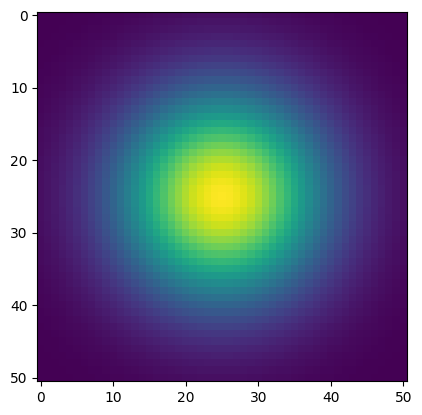

In [10]:
def make_gaussian_blob(blob_width, blob_height):
    assert (
        blob_height % 2 == 1 and blob_width % 2 == 1
    ), "in make_gaussian_blob, blob_height and blob_width must be odd numbers !!"

    # Create a 2D Gaussian blob
    # +-2.5 was derived from experimentation
    x, y = np.meshgrid(
        np.linspace(-2.5, 2.5, blob_width), np.linspace(-2.5, 2.5, blob_height)
    )

    gaussian_blob = np.exp(-0.5 * (x**2 + y**2))

    # scale up the gaussian blob from the 0.0 to 1.0 range to the 0 to 255 range
    gaussian_blob = gaussian_blob

    return gaussian_blob


gaussian_blob = make_gaussian_blob(51, 51)
plt.imshow(gaussian_blob)

100%|██████████| 4/4 [00:00<00:00, 312.91it/s]


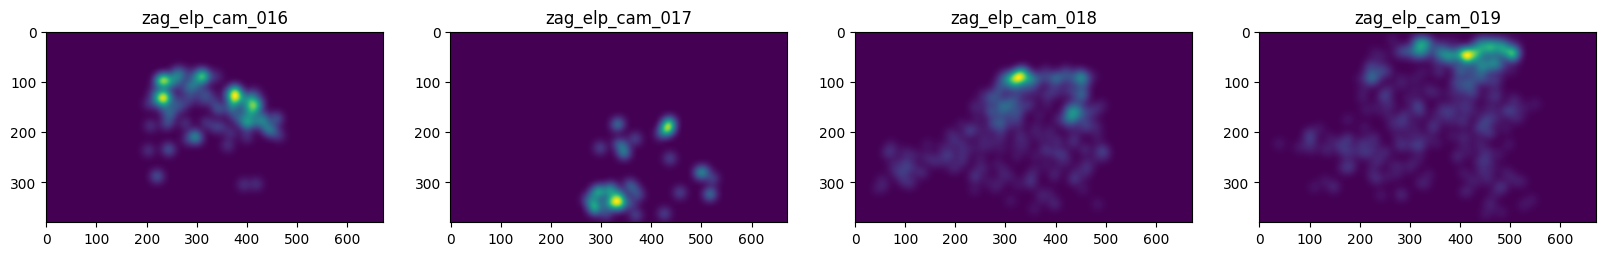

In [11]:
from tqdm import tqdm

coverages = {}

# bbox_data_cols = ["camera", "filename", "label", "x0", "y0", "x1", "y1"]
# bbox_data = []
gh, gw = gaussian_blob.shape

for camera in tqdm(CAMERA_NAMES):
    df = df_labels[df_labels["camera"] == camera]

    coverage = np.zeros((height, width))

    for idx in df.index:
        center_x = int(df.loc[idx, "center_x"] / DOWNSAMPLE_FACTOR)
        center_y = int(df.loc[idx, "center_y"] / DOWNSAMPLE_FACTOR)

        dx0 = center_x - gw // 2
        dy0 = center_y - gh // 2
        dx1 = dx0 + gw
        dy1 = dy0 + gh

        sx0 = 0
        sy0 = 0
        sx1 = gw
        sy1 = gh

        if dx0 < 0:
            sx0 += -dx0
            dx0 = 0
        if dy0 < 0:
            sy0 += -dy0
            dy0 = 0
        if dx1 > coverage.shape[1]:
            sx1 -= dx1 - coverage.shape[1]
            dx1 = coverage.shape[1]
        if dy1 > coverage.shape[0]:
            sy1 -= dy1 - coverage.shape[0]
            dy1 = coverage.shape[0]

        coverage[dy0:dy1, dx0:dx1] += gaussian_blob[sy0:sy1, sx0:sx1]
    coverages[camera] = coverage
NCOLS = 4
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 4))
axs = axs.reshape(-1)
for i, (camera, coverage) in enumerate(coverages.items()):
    ax = axs[i]
    ax.imshow(coverage)
    ax.set_title(camera)

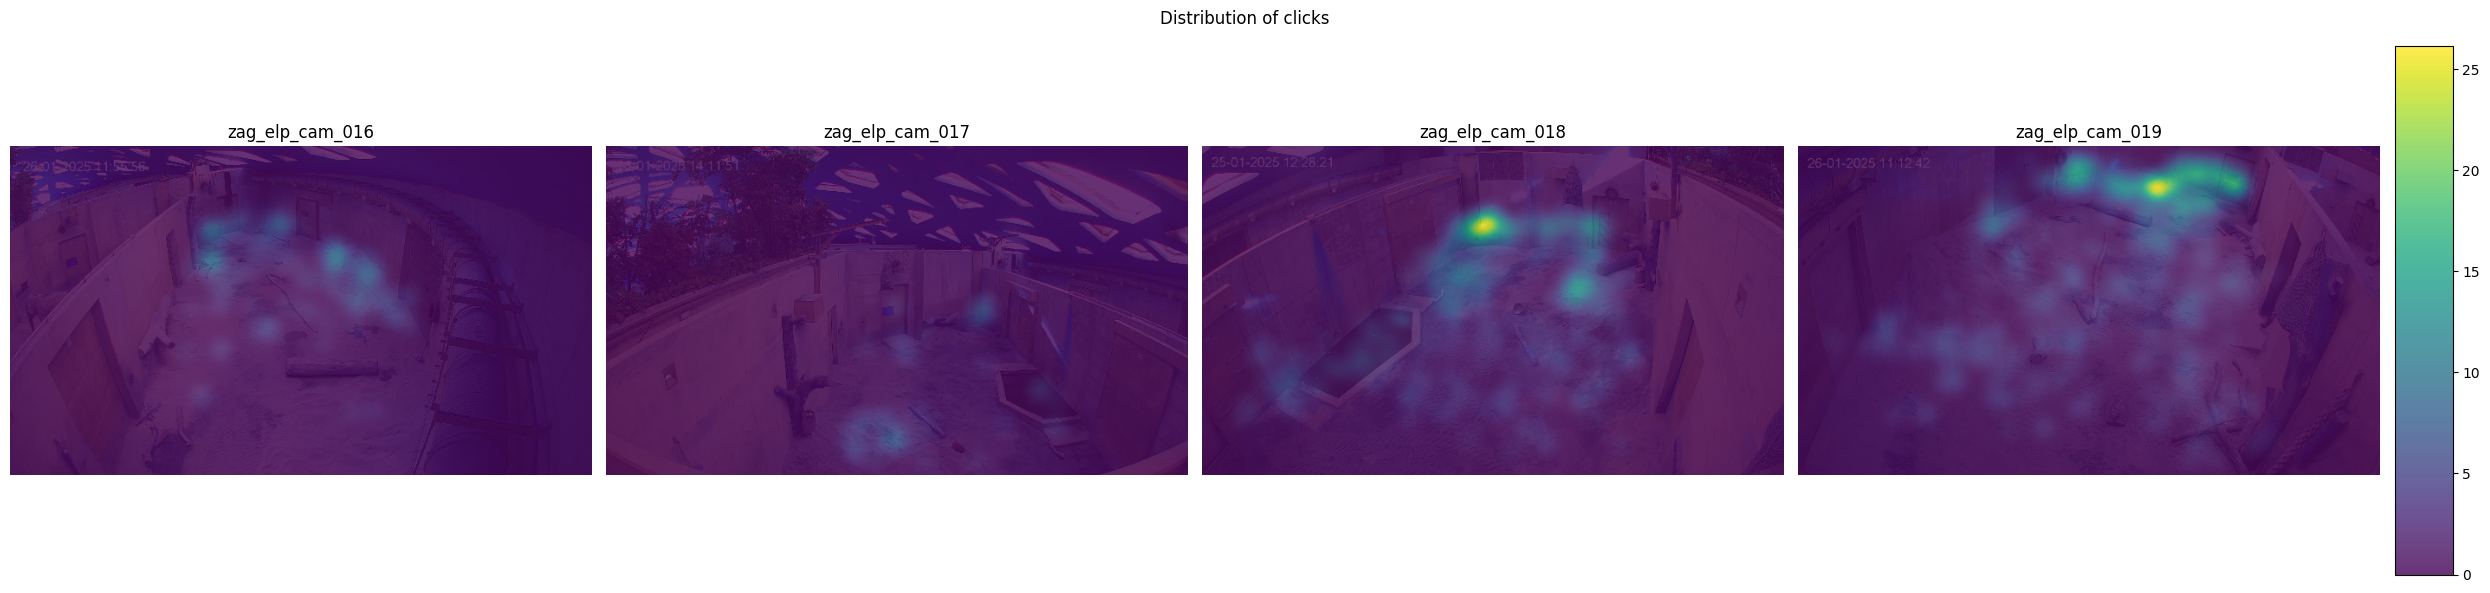

In [12]:
def plot_coverage(limit=100):
    NCOLS = 4
    gs = plt.GridSpec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.1])
    fig = plt.figure(figsize=(25, 6))

    vmax = np.max([np.max([c for c in coverages.values()])])

    for i, (camera, coverage) in enumerate(coverages.items()):
        ax = fig.add_subplot(gs[i])
        ax.imshow(im_test[camera])
        im_clip = np.clip(coverage, 0, limit)
        cb = ax.imshow(im_clip, alpha=0.8, vmin=0, vmax=vmax)
        ax.set_title(camera)
        ax.set_axis_off()
    ax = fig.add_subplot(gs[4])
    plt.colorbar(cb, ax)
    fig.suptitle("Distribution of clicks")
    fig.tight_layout()
    plt.show()


plot_coverage()

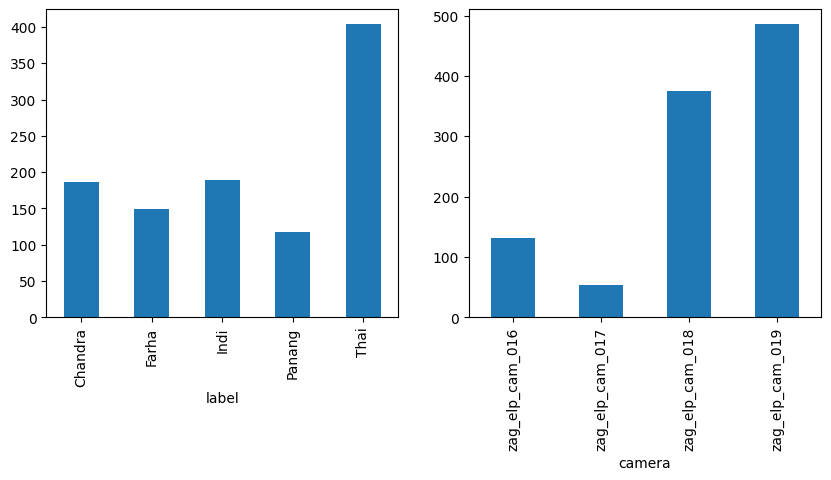

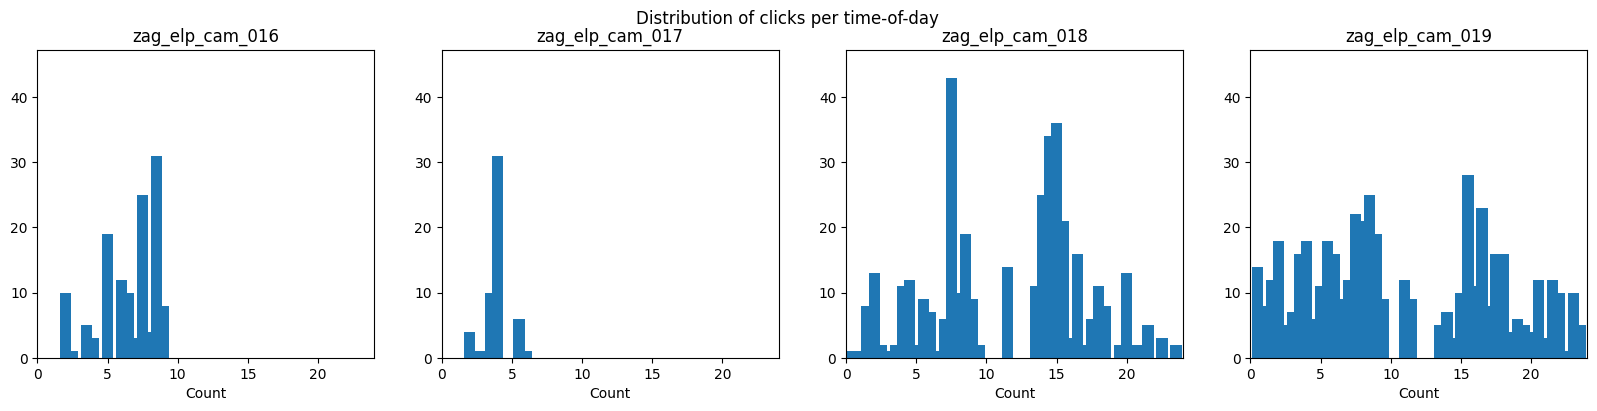

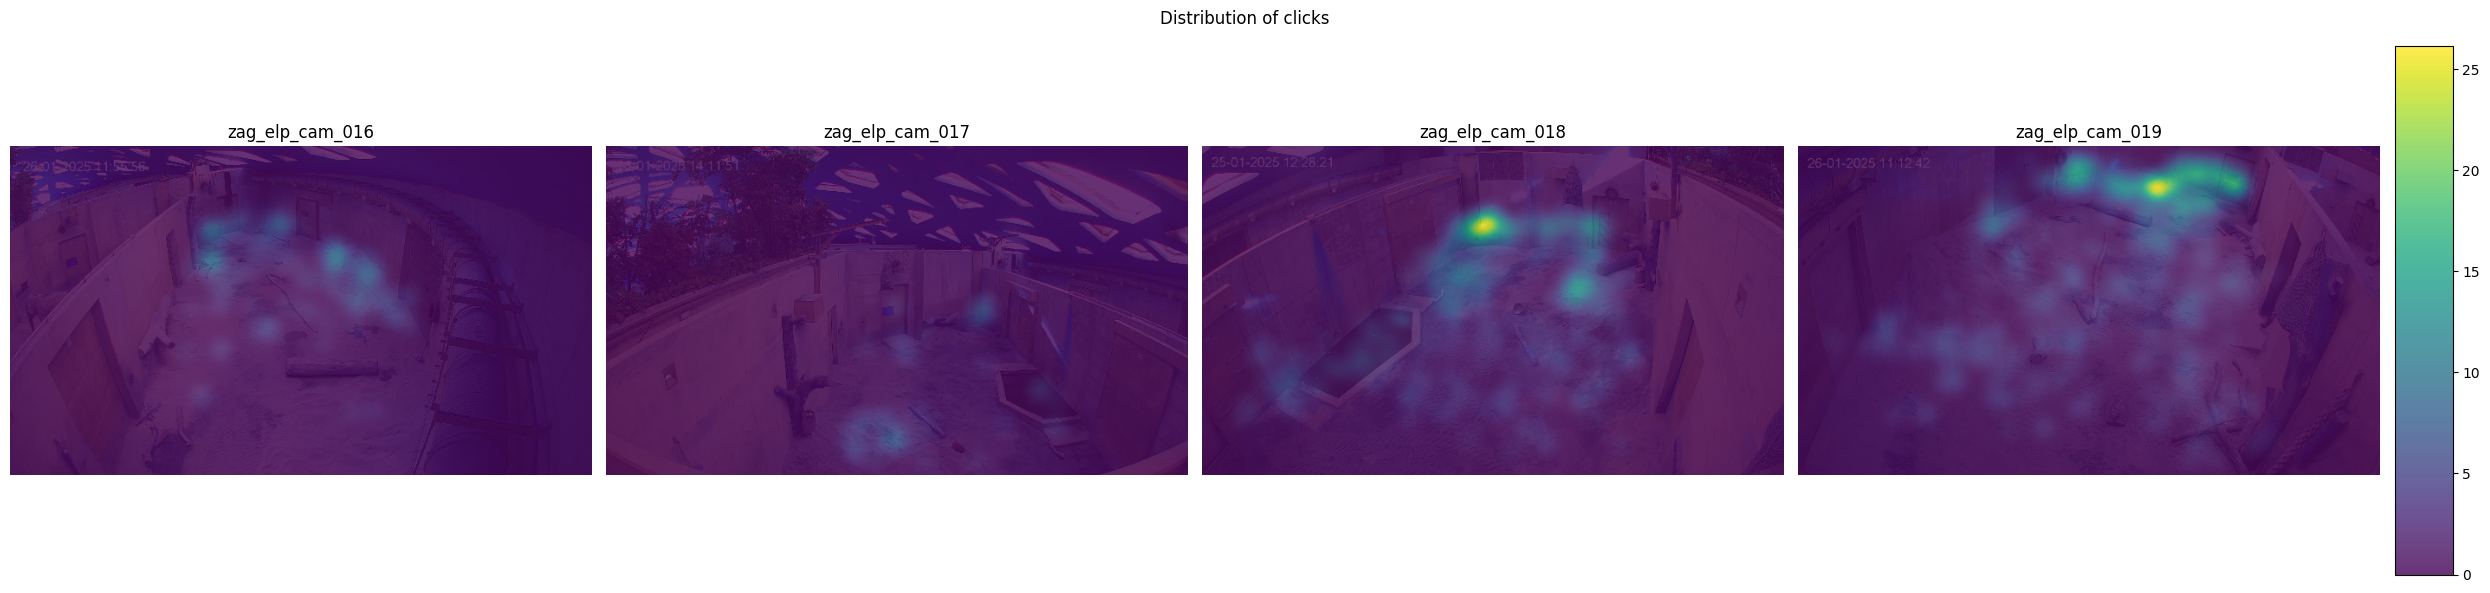

In [13]:
####################################
# Full report
plot_global_hist()
plot_counts_per_time()
plot_coverage()
# plot_coverage(limit=1000)